#1. 환경 설정

In [2]:
!pip install datasets
!pip install transformers
!pip install sentencepiece
!pip install accelerate
!pip install torch

In [3]:
import datasets
from datasets import load_dataset, DatasetDict
from transformers import pipeline
import torch
import re # 텍스트 정리
import pandas as pd # 데이터 확인용

In [4]:
# GPU 사용 가능 여부 확인 및 설정 (Colab에서는 보통 GPU 사용 가능)
device = 0 if torch.cuda.is_available() else -1
print(f"✅사용 가능한 디바이스: {'GPU' if device == 0 else 'CPU'}")

✅사용 가능한 디바이스: GPU


#2. 데이터셋 로드 및 준비

In [5]:
#영화 리뷰
full_dataset = load_dataset("ajaykarthick/imdb-movie-reviews")
print(full_dataset)

# 학습용 train 데이터 중 일부 샘플만 사용
num_samples_to_use = 30
small_dataset = full_dataset["train"].select(range(num_samples_to_use))

# 구조 확인
print("\n구조 확인:")
print(small_dataset[0])

df_check = pd.DataFrame(small_dataset)
print("\n데이터셋 일부 미리보기 (DataFrame):")
display(df_check.head(3)) # Colab 환경에서는 display()가 표 형태로 보여줍니다.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.jsonl:   0%|          | 0.00/53.6M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/13.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/40000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['review', 'label'],
        num_rows: 40000
    })
    test: Dataset({
        features: ['review', 'label'],
        num_rows: 10000
    })
})

구조 확인:
{'review': "Ms Aparna Sen, the maker of Mr & Mrs Iyer, directs this movie about a young girl's struggle to cope with her debilitating condition.<br /><br />Meethi (Konkona Sen) has been an aloof kid ever since childhood and has shown signs of delusion, no one knows why. The dormant tendency however slips out of control, when the job assignment takes her to neighboring Bihar where she's raped by some political goons. The resulting trauma also leads to episodes of manic-depressive psychosis in addition to her schizophrenia. She careens out of control over the years, progressively getting worse and sinking deeper into her private 'world'.<br /><br />The juxtaposition of an 'unsettled' (divorced) elder sister and how her domineering ways make an already bad situation worse, is indicative

,review,label
0,"Ms Aparna Sen, the maker of Mr & Mrs Iyer, dir...",0
1,"I have seen this film only once, on TV, and it...",0
2,I was only fourteen when I first saw the Alien...,1


### 텍스트 전처리 (HTML 태그 제거)

In [6]:
def preprocess_text(example):
    example["review"] = re.sub(r'<br\s*/?>', ' ', example["review"])
    return example

# 전처리 적용
small_dataset = small_dataset.map(preprocess_text)
print("✅ 텍스트 전처리(HTML 태그 제거) 완료.")

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

✅ 텍스트 전처리(HTML 태그 제거) 완료.


## 3. 감정 분석 모델 파이프라인 로드

In [7]:
# 1️⃣ 감정 분석
sentiment_analyzer = pipeline(
    task="text-classification",
    model="SamLowe/roberta-base-go_emotions",
    top_k=1,
    device=device
)

print("✅ 감정 분석 모델 파이프라인 로드 완료.")

# 감정 분석 테스트
test_emotion = sentiment_analyzer("I am very happy today!")
print(f"감정 분석 테스트: {test_emotion[0][0]}")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Device set to use cuda:0


✅ 감정 분석 모델 파이프라인 로드 완료.
감정 분석 테스트: {'label': 'joy', 'score': 0.8936862945556641}


### 감정 분석 적용

In [8]:
def analyze_sentiment(example):
    text = example["review"][:512] # 너무 긴 문장은 잘라줌

    # 감정 분석
    sentiment = sentiment_analyzer(text)

    result = sentiment[0][0]
    example["emotion_label"] = result["label"]
    example["emotion_score"] = result["score"]

    return example

# 감정 분석 적용
print("감정 분석을 시작합니다... (데이터 양에 따라 시간이 소요될 수 있습니다)")
emotion_dataset = small_dataset.map(analyze_sentiment, batched=False)
print("\n감정 분석 완료.")

# 감정 분석 결과 확인
print("\n감정 분석 결과 데이터셋 정보:")
print(emotion_dataset)
print("\n첫 번째 데이터의 리뷰와 감정 결과:")
print("--- 리뷰 ---")
print(emotion_dataset[0]["review"])
print("\n--- 감정 라벨 ---")
print(emotion_dataset[0]["emotion_label"], "(score:", round(emotion_dataset[0]["emotion_score"], 3), ")")

감정 분석을 시작합니다... (데이터 양에 따라 시간이 소요될 수 있습니다)


Map:   0%|          | 0/30 [00:00<?, ? examples/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



감정 분석 완료.

감정 분석 결과 데이터셋 정보:
Dataset({
    features: ['review', 'label', 'emotion_label', 'emotion_score'],
    num_rows: 30
})

첫 번째 데이터의 리뷰와 감정 결과:
--- 리뷰 ---
Ms Aparna Sen, the maker of Mr & Mrs Iyer, directs this movie about a young girl's struggle to cope with her debilitating condition.  Meethi (Konkona Sen) has been an aloof kid ever since childhood and has shown signs of delusion, no one knows why. The dormant tendency however slips out of control, when the job assignment takes her to neighboring Bihar where she's raped by some political goons. The resulting trauma also leads to episodes of manic-depressive psychosis in addition to her schizophrenia. She careens out of control over the years, progressively getting worse and sinking deeper into her private 'world'.  The juxtaposition of an 'unsettled' (divorced) elder sister and how her domineering ways make an already bad situation worse, is indicative of what a fine line there is between abnormal and *seemingly normal*. Ms Se

## 4. 번역 모델 파이프라인 로드

In [9]:
# 2️⃣ 번역(eng > kor)
translator = pipeline(
    task="translation",
    model="facebook/nllb-200-distilled-600M",
    device=device
)

print("✅ 번역 모델 파이프라인 로드 완료.")

# 번역 테스트 (영어 > 한국어)
test_translation = translator("I'm a human.", src_lang="eng_Latn", tgt_lang="kor_Hang")
print(f"번역 테스트: {test_translation}")

config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


✅ 번역 모델 파이프라인 로드 완료.
번역 테스트: [{'translation_text': '난 인간이야'}]


### 번역 적용

In [10]:
def translate_review(example):
    result = translator(example["review"][:512], src_lang="eng_Latn", tgt_lang="kor_Hang")
    example["review_ko"] = result[0]["translation_text"]
    return example

# 번역 적용
print("번역 작업을 시작합니다... (데이터 양에 따라 시간이 소요될 수 있습니다)")
translated_dataset = emotion_dataset.map(translate_review)
print("\n번역 작업 완료.")

# 번역 결과 확인
print("\n번역이 추가된 데이터셋 정보:")
print(translated_dataset)
print("\n첫 번째 데이터의 원문(review)과 번역(review_ko):")
print("--- 원문 (Review) ---")
print(translated_dataset[0]["review"])
print("\n--- 번역 (Korean Translation) ---")
print(translated_dataset[0]["review_ko"])

번역 작업을 시작합니다... (데이터 양에 따라 시간이 소요될 수 있습니다)


Map:   0%|          | 0/30 [00:00<?, ? examples/s]


번역 작업 완료.

번역이 추가된 데이터셋 정보:
Dataset({
    features: ['review', 'label', 'emotion_label', 'emotion_score', 'review_ko'],
    num_rows: 30
})

첫 번째 데이터의 원문(review)과 번역(review_ko):
--- 원문 (Review) ---
Ms Aparna Sen, the maker of Mr & Mrs Iyer, directs this movie about a young girl's struggle to cope with her debilitating condition.  Meethi (Konkona Sen) has been an aloof kid ever since childhood and has shown signs of delusion, no one knows why. The dormant tendency however slips out of control, when the job assignment takes her to neighboring Bihar where she's raped by some political goons. The resulting trauma also leads to episodes of manic-depressive psychosis in addition to her schizophrenia. She careens out of control over the years, progressively getting worse and sinking deeper into her private 'world'.  The juxtaposition of an 'unsettled' (divorced) elder sister and how her domineering ways make an already bad situation worse, is indicative of what a fine line there is between a

# 5. 결과 분석 및 확인

In [11]:
df_final = pd.DataFrame(translated_dataset)

#컬럼 순서 정리
final_columns = ['review', 'review_ko', 'emotion_label', 'emotion_score', 'label']
df_final = df_final[final_columns]

print("\n\n--- 🎬 최종 결과물 ---")
display(df_final.head(3))



--- 🎬 최종 결과물 ---


,review,review_ko,emotion_label,emotion_score,label
0,"Ms Aparna Sen, the maker of Mr & Mrs Iyer, dir...","미스터 & 미스 아이어의 제작자 아파르나 센이 이 영화를 감독하고 있는데, 이 영화...",neutral,0.535457,0
1,"I have seen this film only once, on TV, and it...","이 영화는 TV에서 한 번만 봤는데, 반복되지 않았습니다. 반복적으로 반복되는 쓰레...",fear,0.833828,0
2,I was only fourteen when I first saw the Alien...,저는 14살 때 처음 외계인 영화를 보았고 즉시 그것을 좋아하게 되었습니다. 오리지...,admiration,0.574594,1


# 6. 결과 시각화

In [12]:
!pip install koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 14.0 MB/s eta 0:00:00


--- 📊 결과 시각화 ---

[감정 분석 요약]
sentiment
긍정 (Positive)    16
중립 (Neutral)      9
부정 (Negative)     5
Name: count, dtype: int64


/tmp/ipython-input-499935017.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


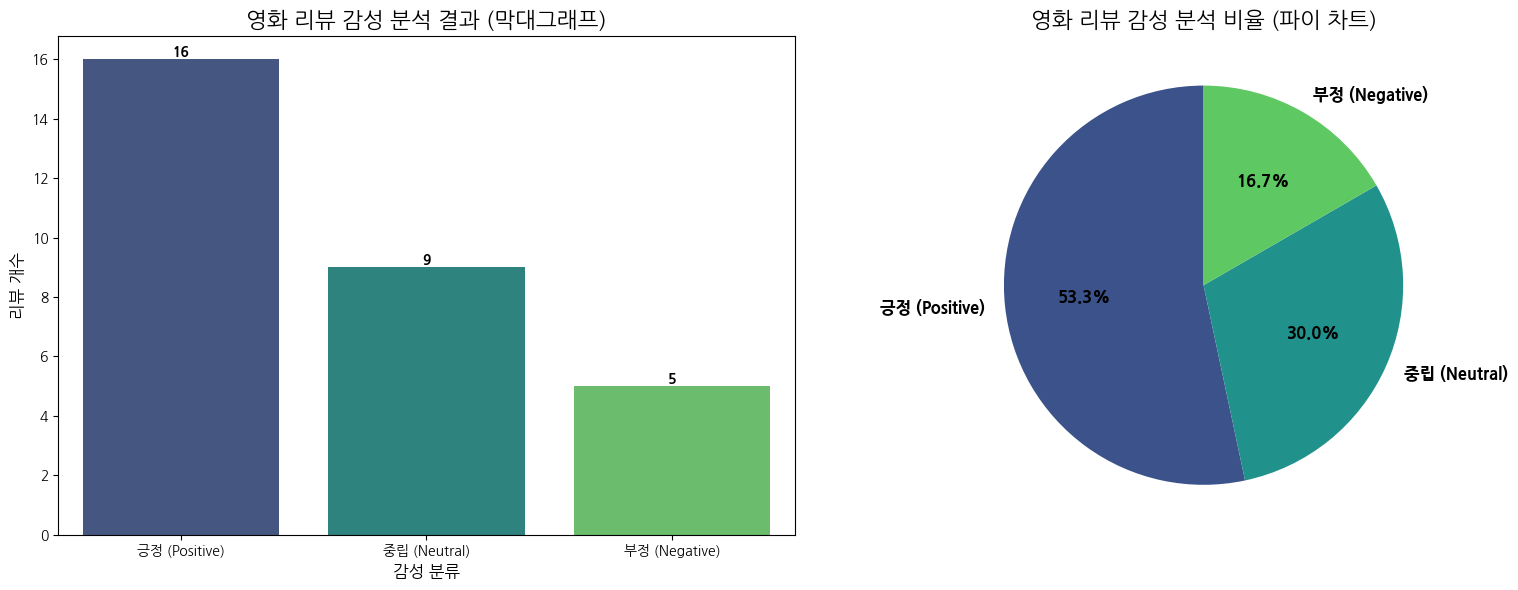


✅ 시각화 완료.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import koreanize_matplotlib

print("--- 📊 결과 시각화 ---")

# 1. 세분화된 감정을 '긍정', '부정', '중립'으로 매핑
def map_emotion_to_sentiment(label):
    positive_emotions = ['admiration', 'amusement', 'approval', 'caring', 'desire', 'excitement', 'gratitude', 'joy', 'love', 'optimism', 'pride', 'relief', 'surprise']
    negative_emotions = ['anger', 'annoyance', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'fear', 'grief', 'nervousness', 'remorse', 'sadness']
    # 나머지는 '중립'으로 처리
    if label in positive_emotions:
        return '긍정 (Positive)'
    elif label in negative_emotions:
        return '부정 (Negative)'
    else:
        return '중립 (Neutral)'

# df_final DataFrame에 'sentiment' 컬럼 추가
df_final['sentiment'] = df_final['emotion_label'].apply(map_emotion_to_sentiment)

# 2. 긍/부정/중립 비율 계산
sentiment_counts = df_final['sentiment'].value_counts()
print("\n[감정 분석 요약]")
print(sentiment_counts)


# 3. 시각화 (막대그래프와 파이 차트)
plt.figure(figsize=(16, 6)) # 전체 그래프 크기 설정

# subplot 1: 막대그래프
plt.subplot(1, 2, 1) # 1행 2열의 첫 번째 그래프
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('영화 리뷰 감성 분석 결과 (막대그래프)', fontsize=16)
plt.xlabel('감성 분류', fontsize=12)
plt.ylabel('리뷰 개수', fontsize=12)
# 막대 위에 개수 표시
for i, count in enumerate(sentiment_counts.values):
    plt.text(i, count + 0.1, str(count), ha='center', fontweight='bold')


# subplot 2: 파이 차트
plt.subplot(1, 2, 2) # 1행 2열의 두 번째 그래프
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('viridis', len(sentiment_counts)),
        startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title('영화 리뷰 감성 분석 비율 (파이 차트)', fontsize=16)
plt.ylabel('') # 불필요한 y축 라벨 제거

plt.tight_layout() # 그래프 간격 자동 조절
plt.show()

print("\n✅ 시각화 완료.")

# 7. CSV 파일 저장

In [15]:
# 최종 DataFrame을 CSV 파일로 저장
df_final.to_csv("movie_reviews_analysis.csv", index=False, encoding='utf-8-sig')

print("✅ CSV 파일 저장 완료.")

✅ CSV 파일 저장 완료.
